浏览用户数: 984080
加购用户数: 737393
购买用户数: 670370

浏览→加购转化率: 74.93%
加购→购买转化率: 90.91%


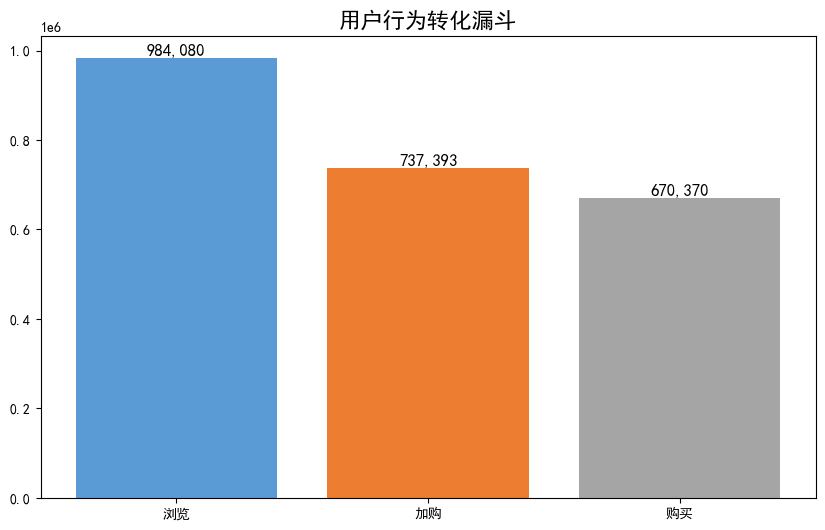

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取清洗后数据
df = pd.read_csv('../data/cleaned/user_behavior_cleaned.csv')

# 用户级漏斗
user_behavior = df.groupby('用户ID')['行为类型'].apply(set)

pv_users = user_behavior.apply(lambda x: 'pv' in x).sum()
cart_users = user_behavior.apply(lambda x: 'cart' in x).sum()
buy_users = user_behavior.apply(lambda x: 'buy' in x).sum()

print(f"浏览用户数: {pv_users}")
print(f"加购用户数: {cart_users}")
print(f"购买用户数: {buy_users}")

# 转化率
print(f"\n浏览→加购转化率: {cart_users/pv_users:.2%}")
print(f"加购→购买转化率: {buy_users/cart_users:.2%}")

# 漏斗图
stages = ['浏览', '加购', '购买']
counts = [pv_users, cart_users, buy_users]

plt.figure(figsize=(10, 6))
bars = plt.bar(stages, counts, color=['#5B9BD5', '#ED7D31', '#A5A5A5'])
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{count:,}', ha='center', fontsize=12)
plt.title('用户行为转化漏斗', fontsize=16)
plt.savefig('../output/charts/01_用户漏斗.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd

# 读取清洗后数据
df = pd.read_csv('../data/cleaned/user_behavior_cleaned.csv')

# 每个用户的行为集合
user_summary = df.groupby('用户ID')['行为类型'].apply(lambda x: ','.join(sorted(set(x)))).reset_index()
user_summary.columns = ['用户ID', '行为集合']

# 标记是否有各行为
user_summary['有浏览'] = user_summary['行为集合'].apply(lambda x: 'pv' in x)
user_summary['有加购'] = user_summary['行为集合'].apply(lambda x: 'cart' in x)
user_summary['有购买'] = user_summary['行为集合'].apply(lambda x: 'buy' in x)

print(user_summary.head())
print(f"\n总用户数：{len(user_summary)}")

# 保存用户汇总
user_summary.to_csv('../data/cleaned/user_summary.csv', index=False)
print("已保存到 ../data/cleaned/user_summary.csv")

# 生成漏斗数据
funnel_data = pd.DataFrame({
    '环节': ['浏览', '加购', '购买'],
    '用户数': [
        user_summary['有浏览'].sum(),
        user_summary['有加购'].sum(),
        user_summary['有购买'].sum()
    ]
})
funnel_data.to_csv('../data/cleaned/funnel_data.csv', index=False)
print("\n漏斗数据：")
print(funnel_data)

   用户ID             行为集合   有浏览    有加购    有购买
0     1               pv  True  False  False
1     2  buy,cart,fav,pv  True   True   True
2     3      cart,fav,pv  True   True  False
3     4      buy,cart,pv  True   True   True
4     5               pv  True  False  False

总用户数：987984
已保存到 ../data/cleaned/user_summary.csv

漏斗数据：
   环节     用户数
0  浏览  984080
1  加购  737393
2  购买  670370
